# **Homework 3**
## ECEN 5156 - Physical Optics
### *Samuel Arnold*
### *10/05/26*
***

## 4.) Pulse propagation in dispersive media

### 4a.)

$$\sigma(z) = \sigma\sqrt{1 + \left(\frac{2Dz}{\sigma}\right)^2}$$

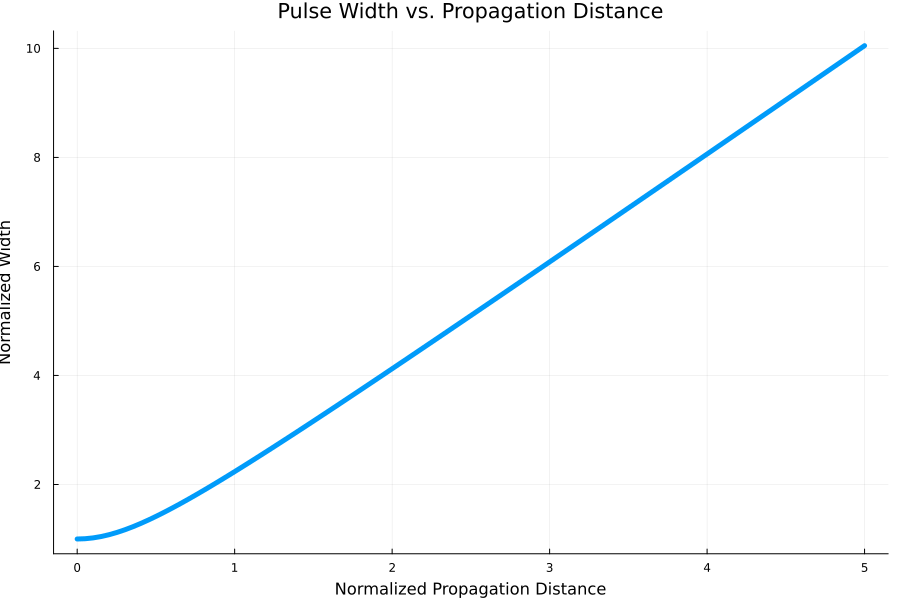

In [9]:
using Plots

gr()

default(size=(900, 600))

sigma = 1
D = 1

z = range(0,5 , length=100)

sigma_z = sigma .* sqrt.(1 .+ ((2 .* D .* z)/(sigma.^2)).^2)

plot(
    z,
    sigma_z,
    title="Pulse Width vs. Propagation Distance",
    xlabel="Normalized Propagation Distance",
    ylabel="Normalized Width",
    label="",
    lw=5
)


## 5.) EXTRA CREDIT: Pulse propagation in dispersive media

### 5a.)

$$n(\lambda) = \sqrt{1 + \frac{0.6961663 \lambda^2}{\lambda^2 - (0.0684043)^2} + \frac{0.4079426 \lambda^2}{\lambda^2 - (0.1162414)^2} + \frac{0.8974794 \lambda^2}{\lambda^2 - (9.896161)^2}}$$

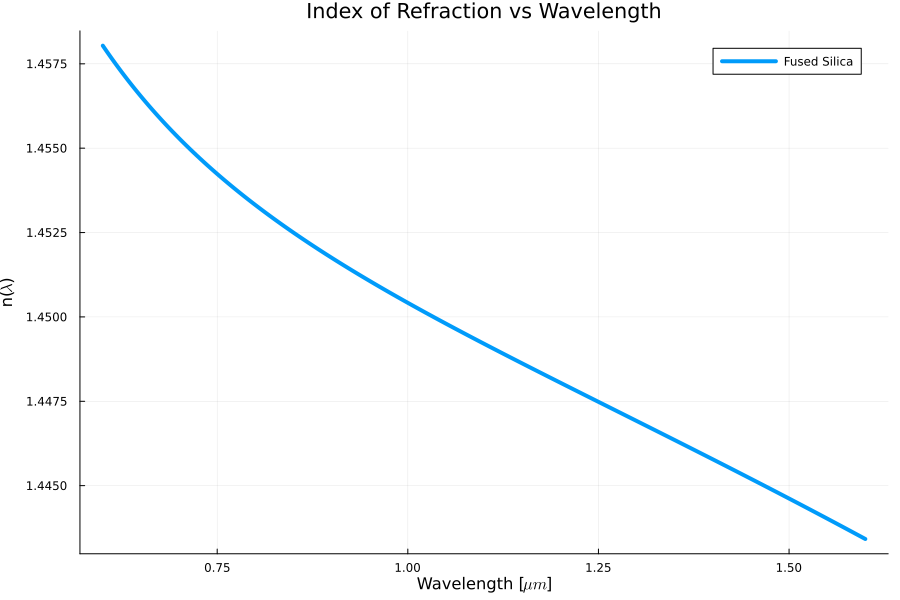

In [46]:
using Plots

gr()

default(size=(900, 600))

c = 299792.458 # Speed of light in km/s
lambda = range(0.6, 1.6, length=500)


B1, C1 = 0.6961663, 0.0684043^2
B2, C2 = 0.4079426, 0.1162414^2
B3, C3 = 0.8974794, 9.896161^2

n = sqrt.(
     1 .+ (B1 .* lambda.^2) ./ (lambda.^2 .- C1) .+ 
    (B2 .* lambda.^2) ./ (lambda.^2 .- C2) .+ 
    (B3 .* lambda.^2) ./ (lambda.^2 .- C3)
    )

p1 = plot(
    lambda,
    n,
    title="Index of Refraction vs Wavelength",
    xlabel=raw"Wavelength [$\mu m$]",
    ylabel=raw"n($\lambda$)",
    label="Fused Silica",
    lw=4
)


### b.)

$$v_g = \frac{L}{\tau_g}$$

$$\tau_g = \frac{L}{c} \left(n-\lambda \frac{\partial n}{\partial \lambda}\right)$$

Wavelength at zero time difference: 1.2733466933867736 μm


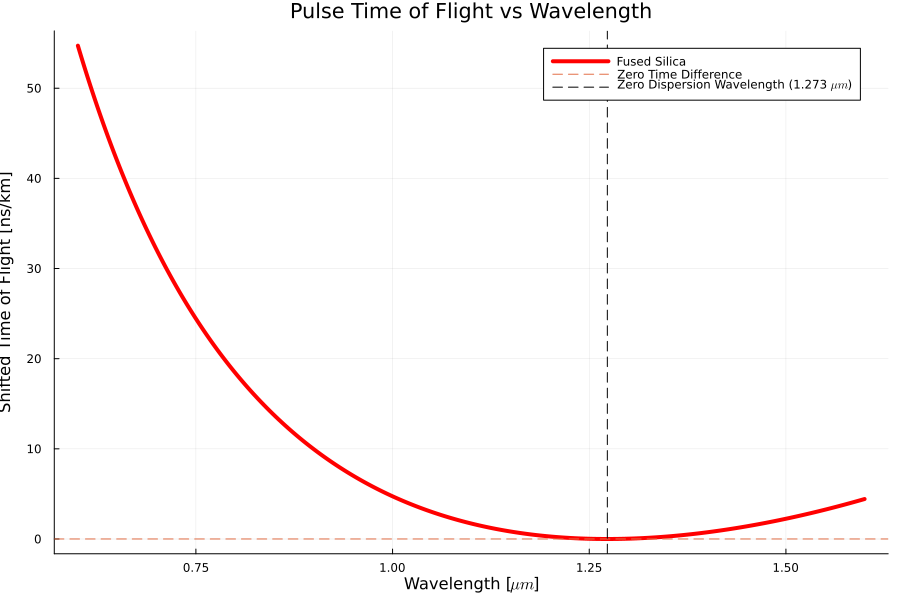

In [ ]:
L = 1 # km

dn_dlambda = -(lambda ./ n) .* (
    B1 * C1 ./ (lambda.^2 .- C1).^2 .+ 
    B2 * C2 ./ (lambda.^2 .- C2).^2 .+ 
    B3 * C3 ./ (lambda.^2 .- C3).^2
)

tau_g = L * (1e9 / c) .* (n .- lambda .* dn_dlambda)
tau_shifted = tau_g .- minimum(tau_g)


min_index = argmin(tau_shifted)
println("Wavelength at zero time difference: ", lambda[min_index], " μm")


p2 = plot(
    lambda,
    tau_shifted,
    title="Pulse Time of Flight vs Wavelength",
    xlabel=raw"Wavelength [$\mu m$]",
    ylabel="Shifted Time of Flight [ns/km]",
    label="Fused Silica",
    lw=4,
    color="red"
)

hline!(
    p2,
    [0],
    linestyle=:dash,
    label="Zero Time Difference"
)

vline!(
    p2,
    [1.273],
    linestyle=:dash,
    label=raw"Zero Dispersion Wavelength (1.273 $\mu m$)",
    color="black"
)


### c.) 

$$D = - \frac{\lambda}{c} \frac{\partial^2 n}{\partial \lambda^2}$$

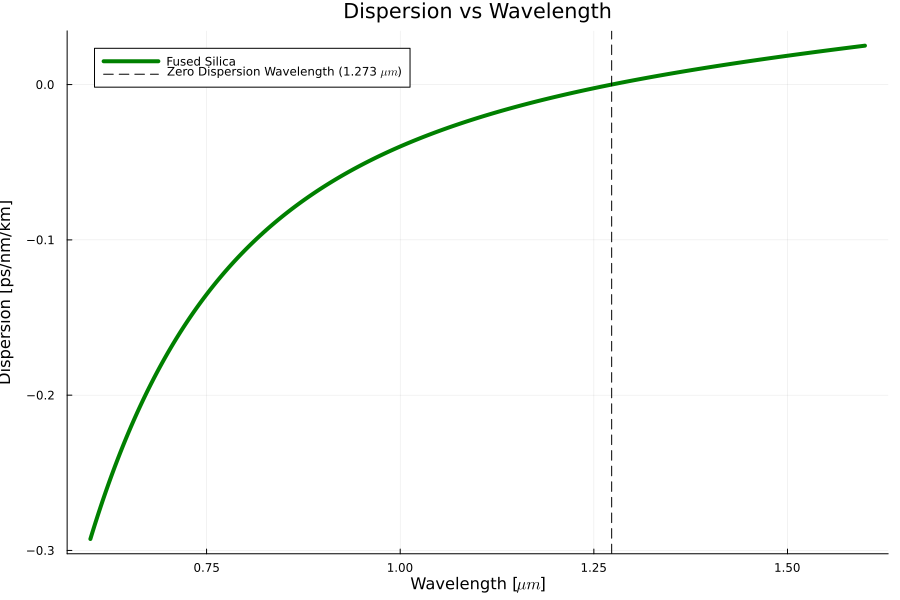

In [45]:
d2n_dlambda2 = (1.0 ./ n) .* (
    B1 * C1 .* (3 .* lambda.^2 .+ C1) ./ (lambda.^2 .- C1).^3 .+
    B2 * C2 .* (3 .* lambda.^2 .+ C2) ./ (lambda.^2 .- C2).^3 .+
    B3 * C3 .* (3 .* lambda.^2 .+ C3) ./ (lambda.^2 .- C3).^3 .- 
    dn_dlambda.^2
)

D = -(1e6 / c) .* lambda .* d2n_dlambda2

p2 = plot(
    lambda,
    D,
    title="Dispersion vs Wavelength",
    xlabel=raw"Wavelength [$\mu m$]",
    ylabel="Dispersion [ps/nm/km]",
    label="Fused Silica",
    lw=4,
    color="green"
)


vline!(
    p2,
    [1.273],
    linestyle=:dash,
    label=raw"Zero Dispersion Wavelength (1.273 $\mu m$)",
    color="black"
)

Below 1.273 $\mu m$, the dispersion is normal, but past 1.273 $\mu m$ it is anomalous.

### 4d.)

If transmitting on multiple channels using different wavelengths, there would be an expected dispersion width due to the material properties of the silica fiber. As a result, the distance of the pulses need to be far enough apart to not merge into each other with the dispersion, but this yields a limit in the transmission rate.

The optimum wavelength to transmit would be around the 1.273 $\mu m$ wavelength as the dispersion is the smallest, leading to tighter packing of pulses to optimally fit a higher data rate in the same fiber.